In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shahedurrahmanrafin/capstone-csv-2nd/Dataset of Diabetes .csv


# =========================================
# STEP 0: Import Libraries
# =========================================


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Visualization style

In [4]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

# =========================================
# STEP 2: Load Dataset
# =========================================

In [5]:

file_path = "/kaggle/input/datasets/shahedurrahmanrafin/capstone-csv-2nd/Dataset of Diabetes .csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nSummary Statistics:")
print(df.describe())


Dataset Loaded Successfully

Dataset Shape: (1000, 14)

Columns:
Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')

First 5 Rows:
    ID  No_Pation Gender  AGE  Urea  Cr  HbA1c  Chol   TG  HDL  LDL  VLDL  \
0  502      17975      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5   
1  735      34221      M   26   4.5  62    4.9   3.7  1.4  1.1  2.1   0.6   
2  420      47975      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5   
3  680      87656      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5   
4  504      34223      M   33   7.1  46    4.9   4.9  1.0  0.8  2.0   0.4   

    BMI CLASS  
0  24.0     N  
1  23.0     N  
2  24.0     N  
3  24.0     N  
4  21.0     N  

Summary Statistics:
                ID     No_Pation          AGE         Urea           Cr  \
count  1000.000000  1.000000e+03  1000.000000  1000.000000  1000.000000   
mean    340.500000  2.705514e+05    53.528

# =========================================
# STEP 3: Exploratory Data Analysis
# =========================================

# -----------------------------
# Class Distribution
# -----------------------------


/tmp/ipykernel_55/574200845.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='CLASS', data=df, palette="viridis", order=df['CLASS'].value_counts().index)


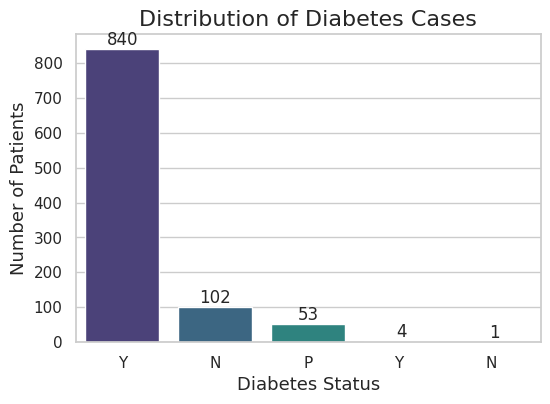

In [9]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='CLASS', data=df, palette="viridis", order=df['CLASS'].value_counts().index)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Diabetes Cases")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Patients")

plt.show()


# =========================================
# Numerical Feature Distribution
# =========================================


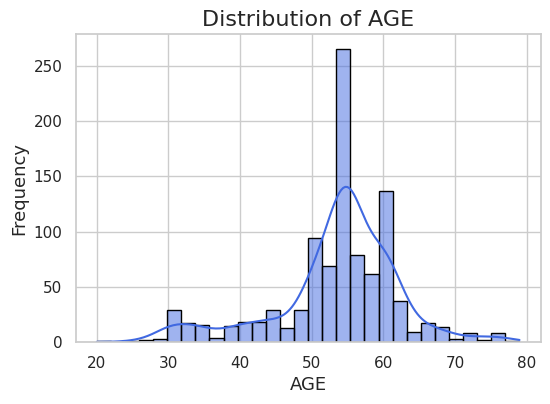

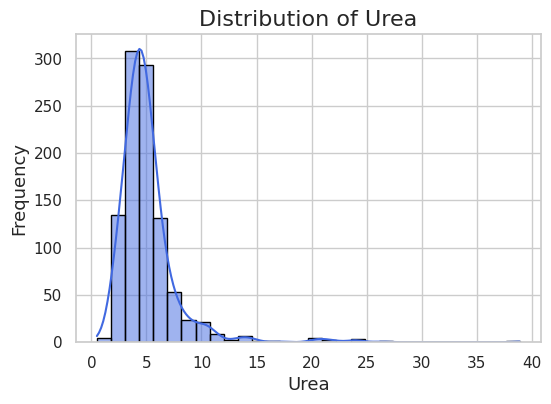

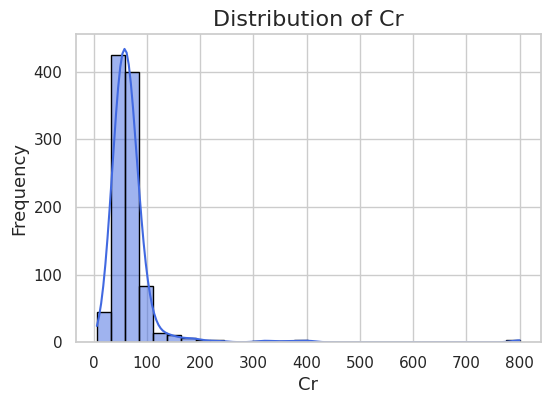

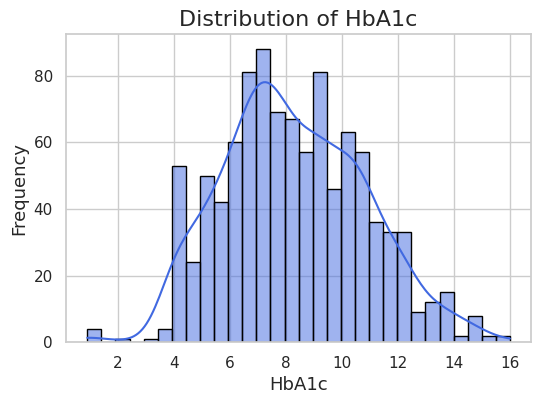

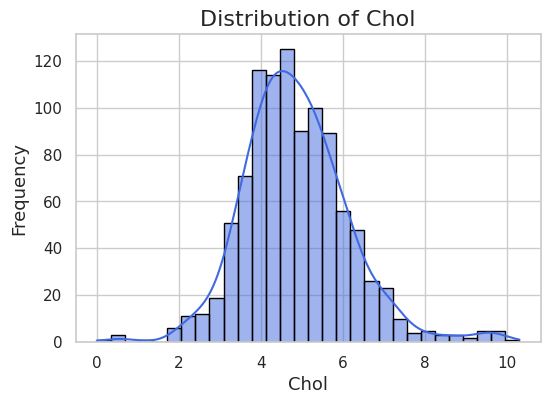

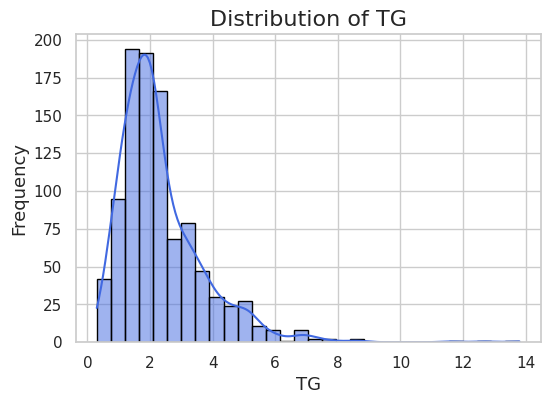

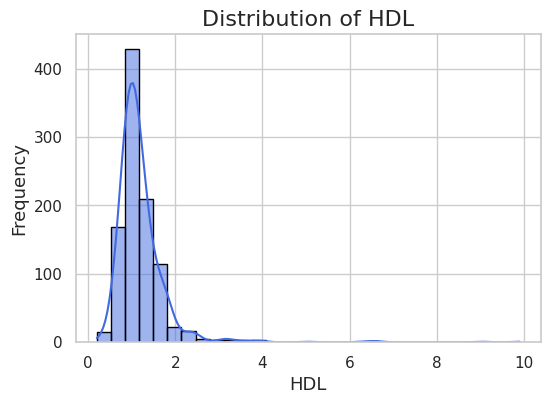

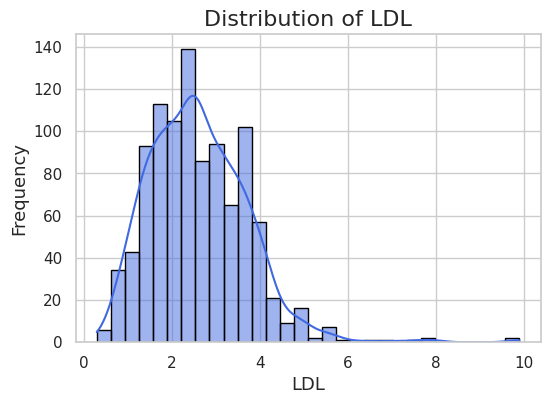

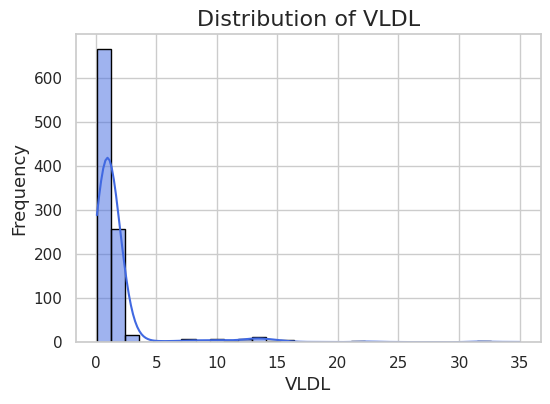

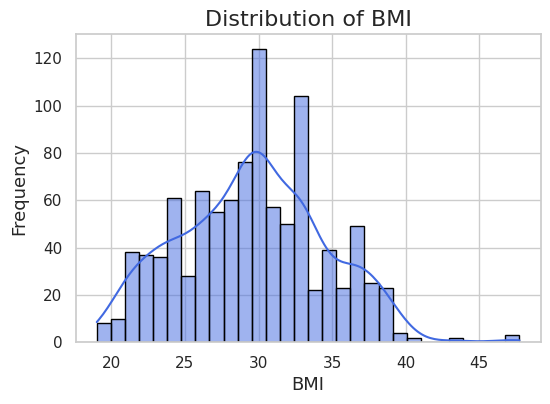

In [11]:
numerical_features = [
    "AGE",
    "Urea",
    "Cr",
    "HbA1c",
    "Chol",
    "TG",
    "HDL",
    "LDL",
    "VLDL",
    "BMI"
]

for feature in numerical_features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[feature],
        kde=True,
        bins=30,
        color="royalblue",
        edgecolor="black"
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

# =========================================
# Boxplots for Outlier Detection
# =========================================


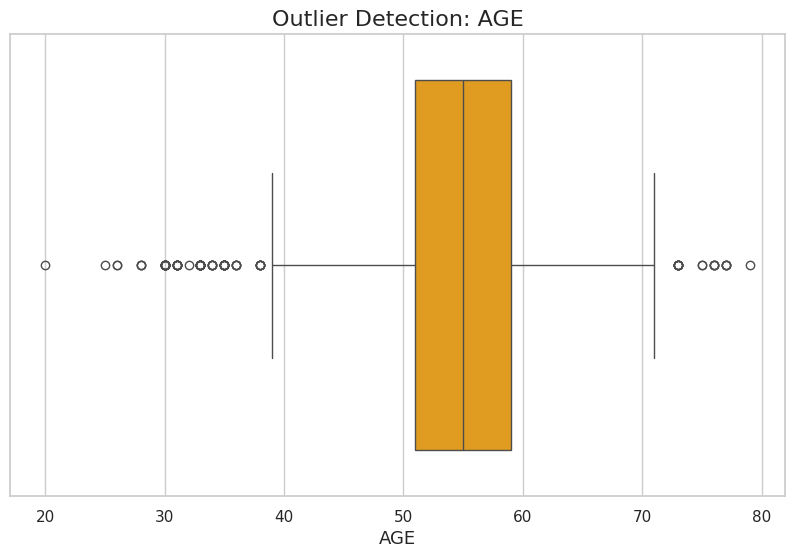

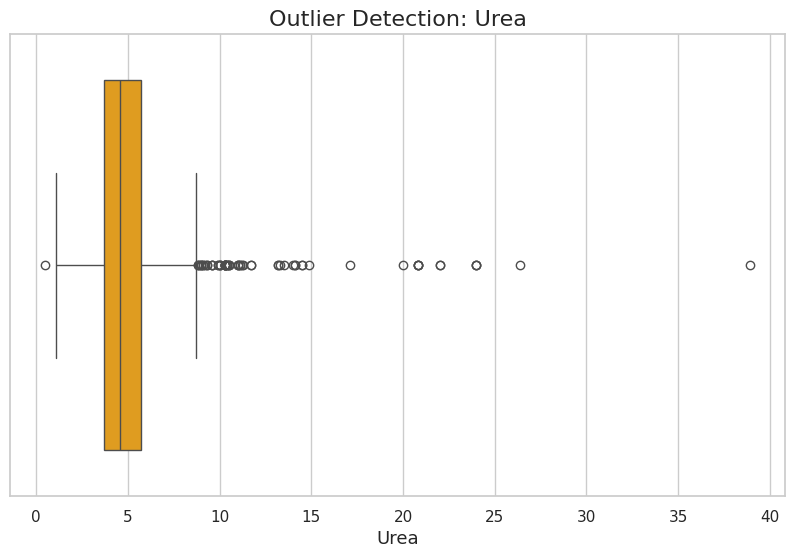

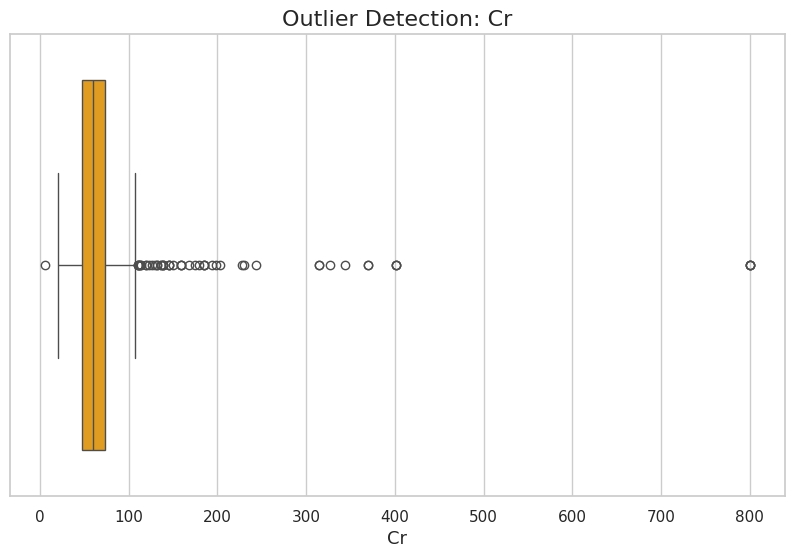

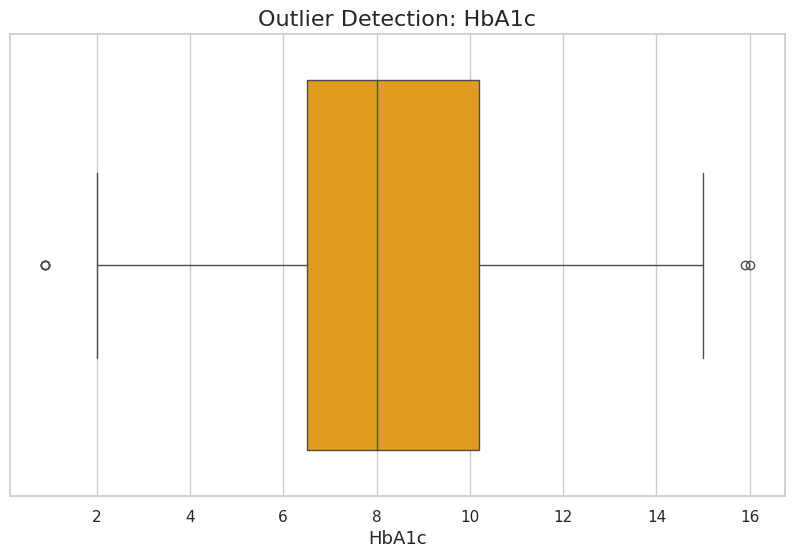

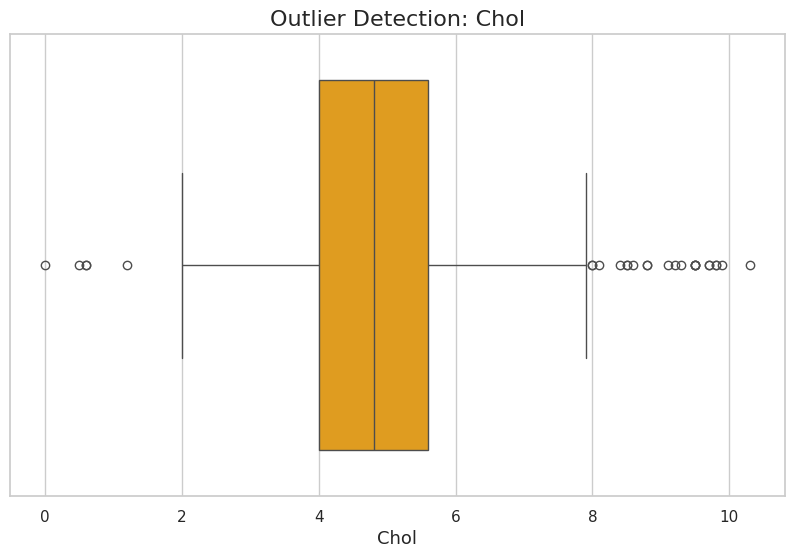

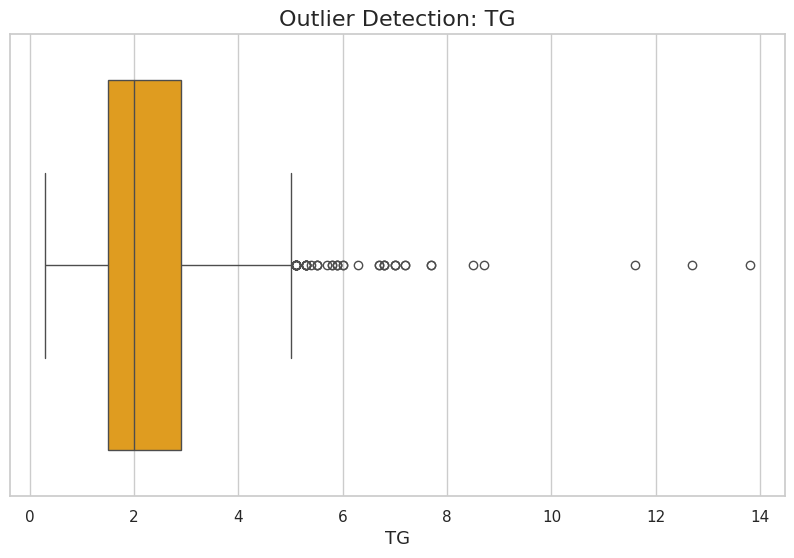

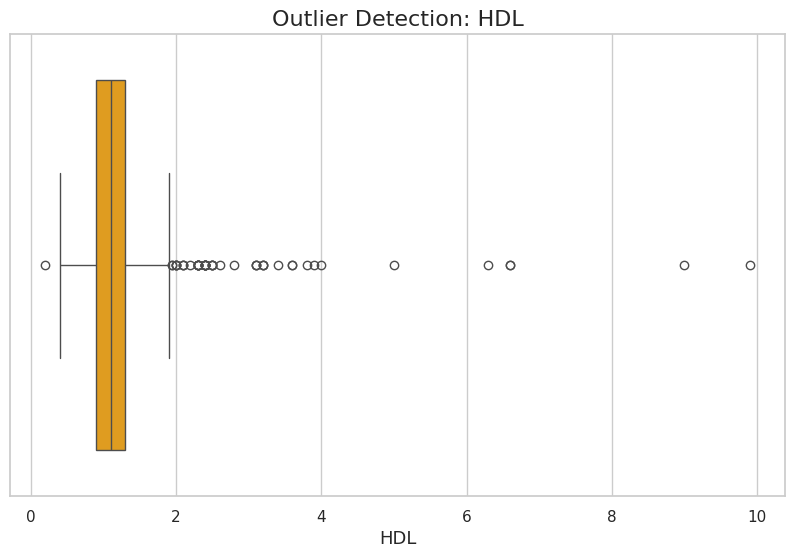

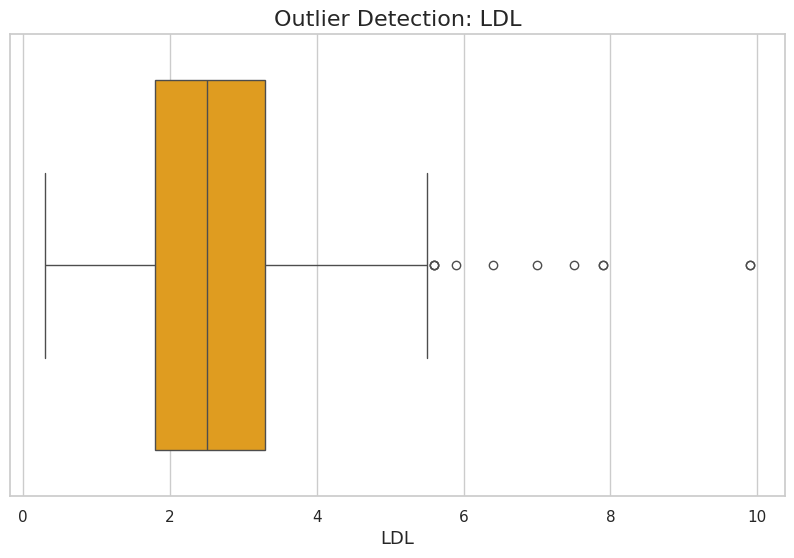

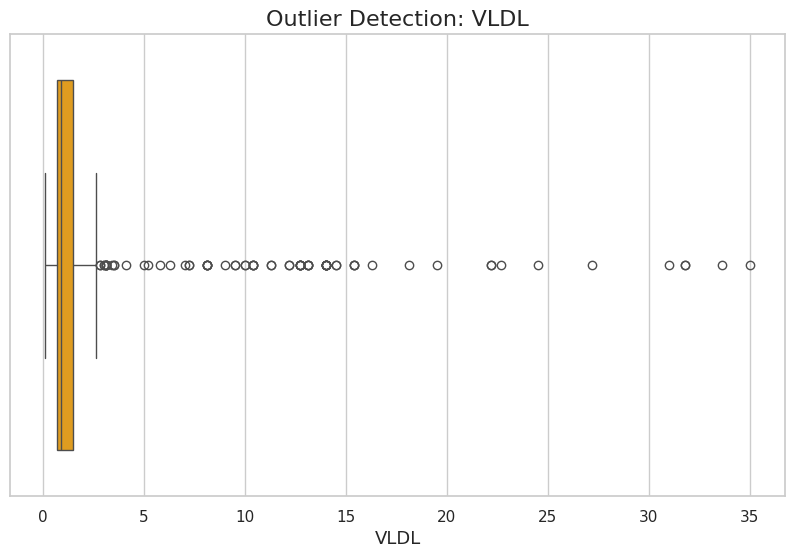

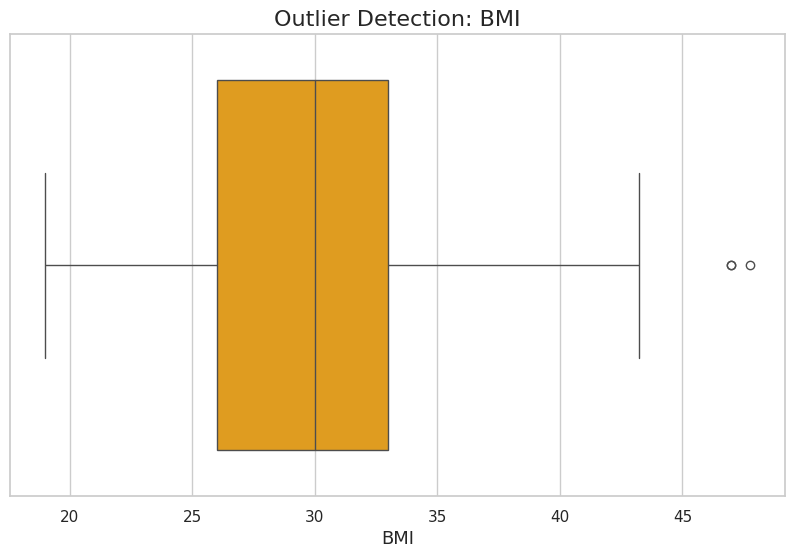

In [12]:
for feature in numerical_features:

    plt.figure()

    sns.boxplot(
        x=df[feature],
        color="orange"
    )

    plt.title(f"Outlier Detection: {feature}")
    plt.xlabel(feature)

    plt.show()


# =========================================
# Correlation Heatmap
# =========================================

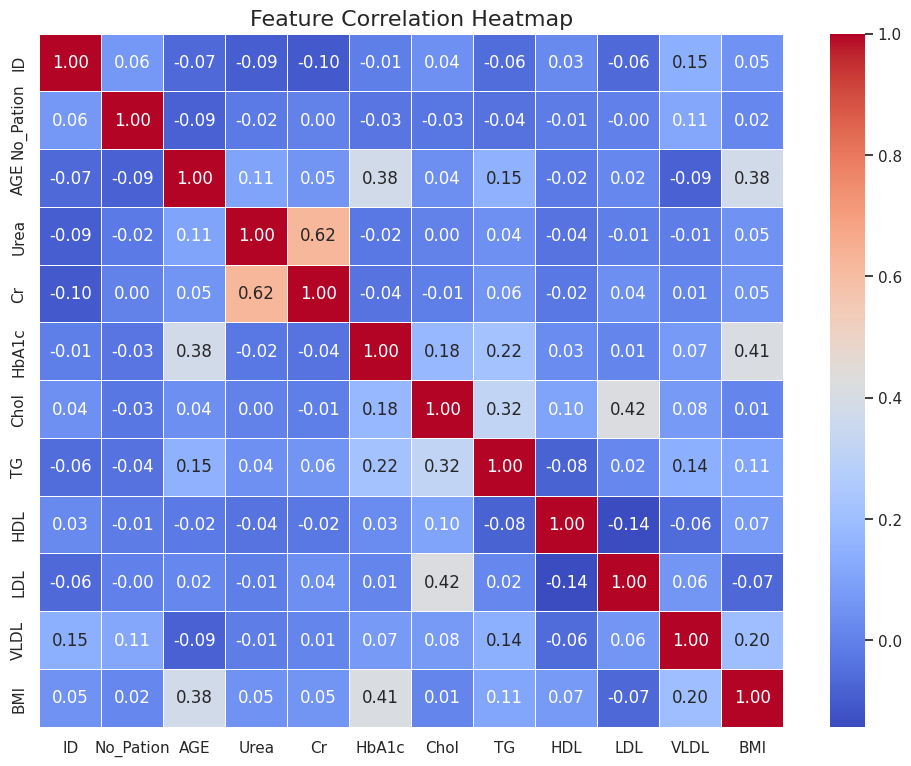

In [13]:

plt.figure(figsize=(12,9))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()



# =========================================
# Relationship Between Important Features and Diabetes
# =========================================


/tmp/ipykernel_55/3865032952.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


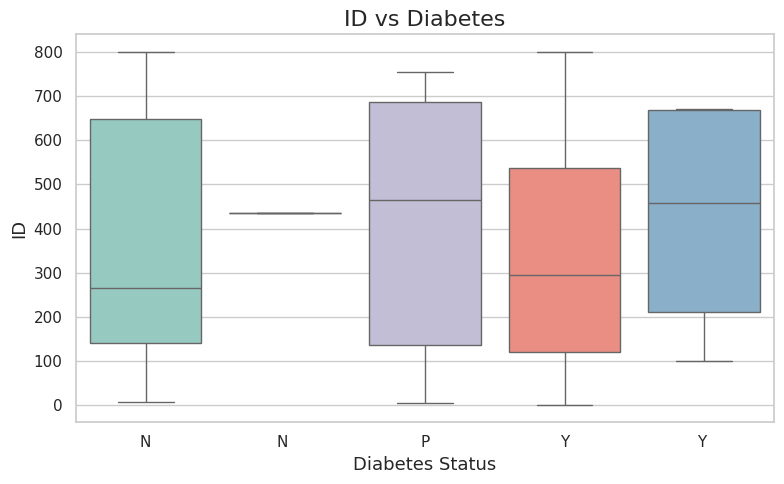

/tmp/ipykernel_55/3865032952.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


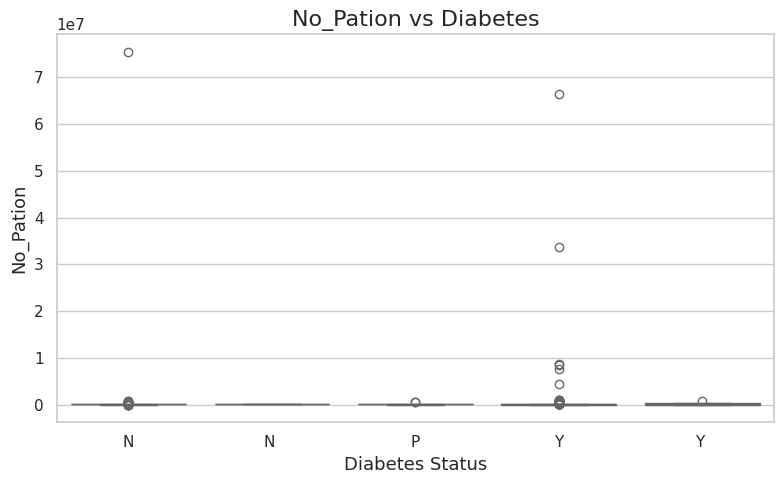

/tmp/ipykernel_55/3865032952.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


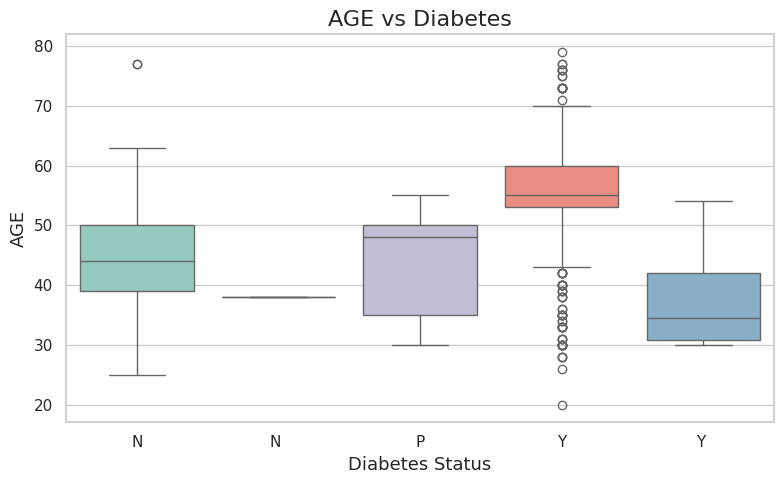

/tmp/ipykernel_55/3865032952.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


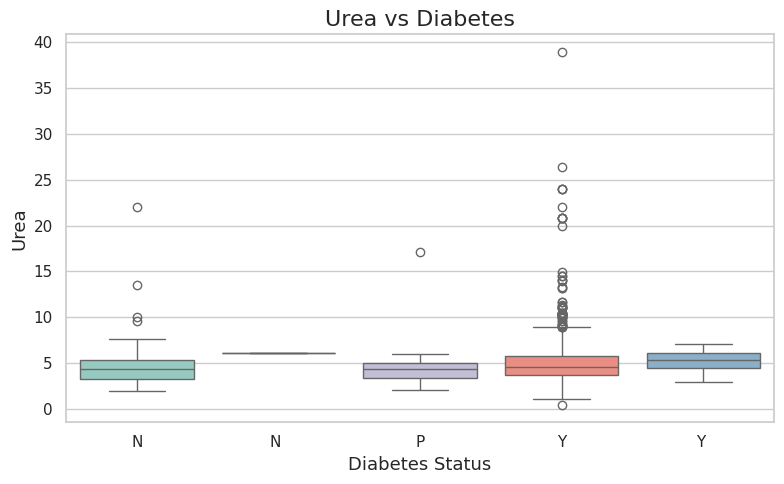

/tmp/ipykernel_55/3865032952.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


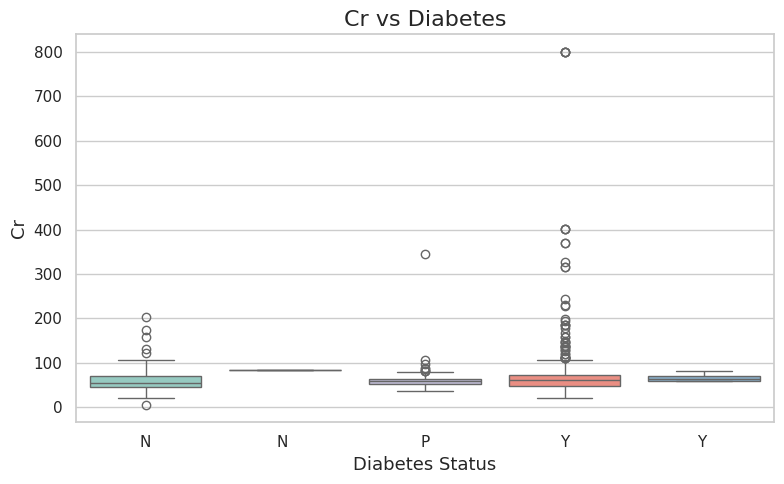

/tmp/ipykernel_55/3865032952.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


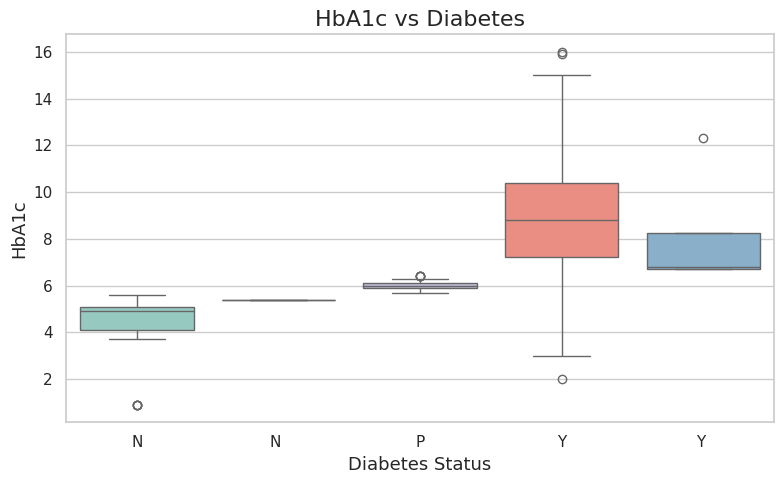

/tmp/ipykernel_55/3865032952.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


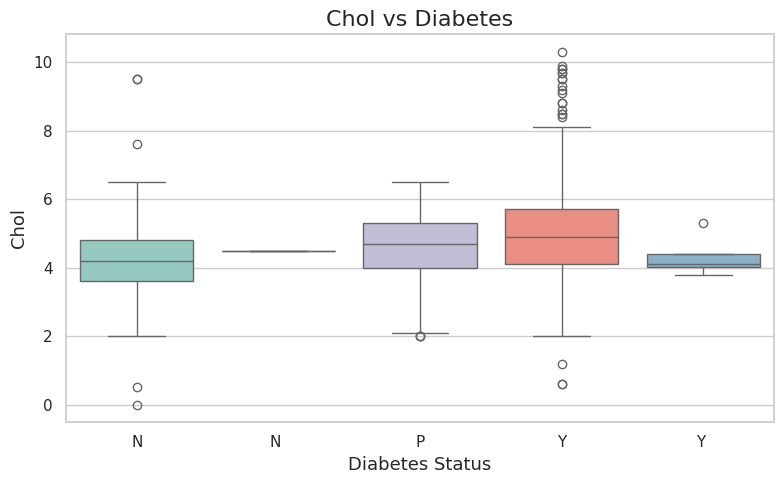

/tmp/ipykernel_55/3865032952.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


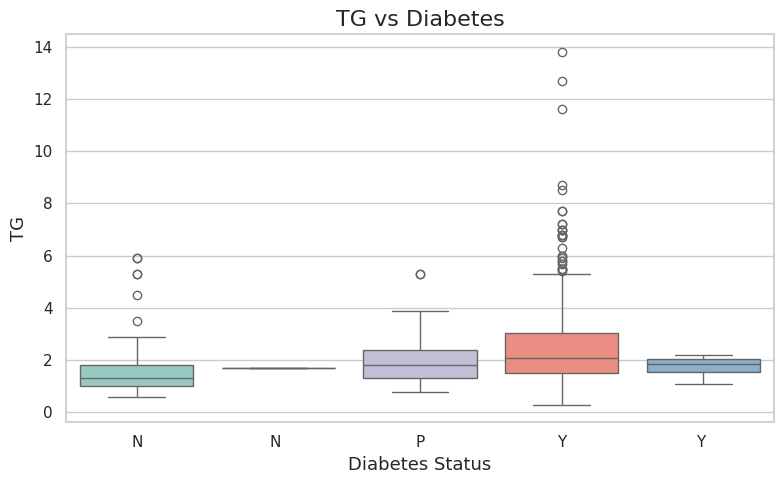

/tmp/ipykernel_55/3865032952.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


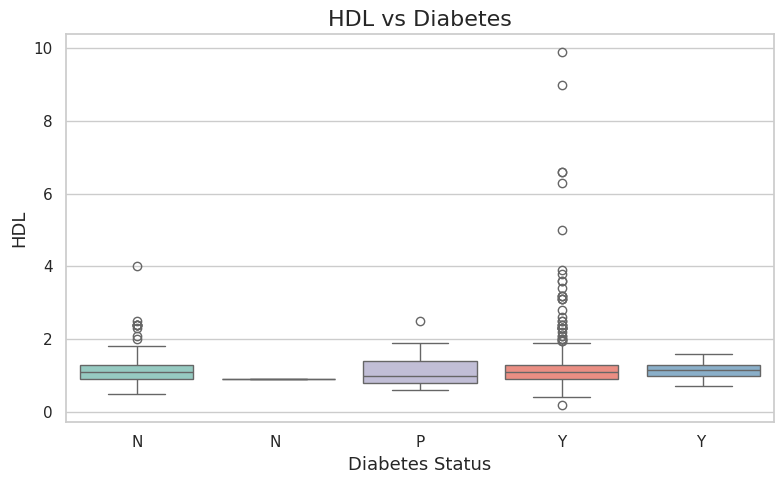

/tmp/ipykernel_55/3865032952.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


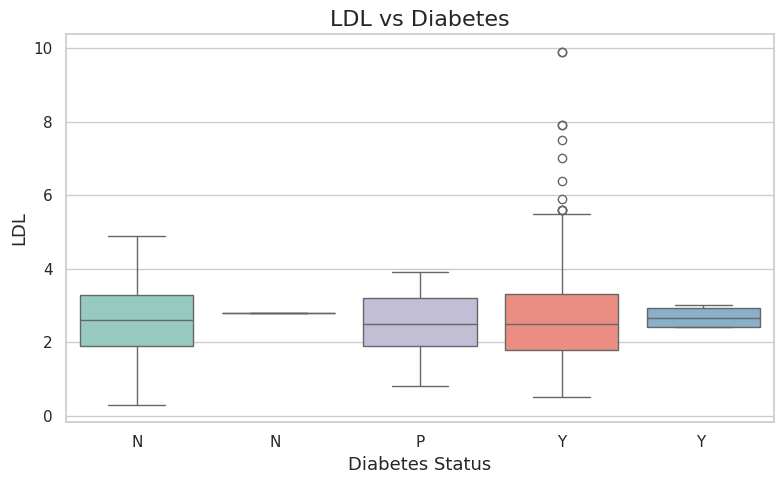

/tmp/ipykernel_55/3865032952.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


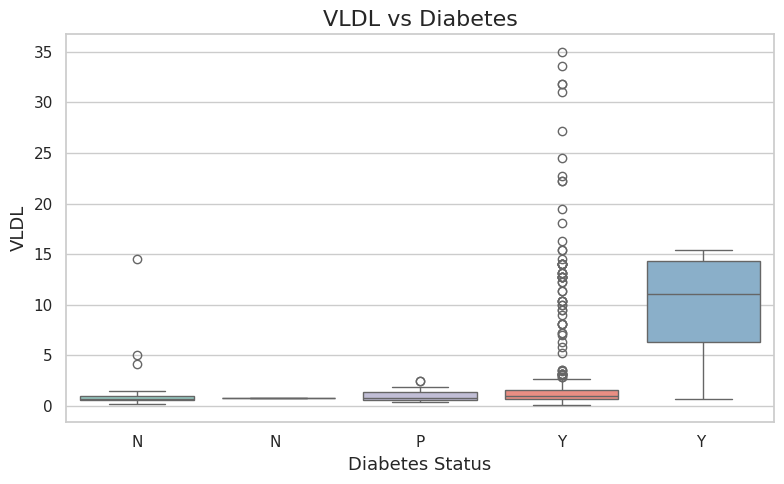

/tmp/ipykernel_55/3865032952.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


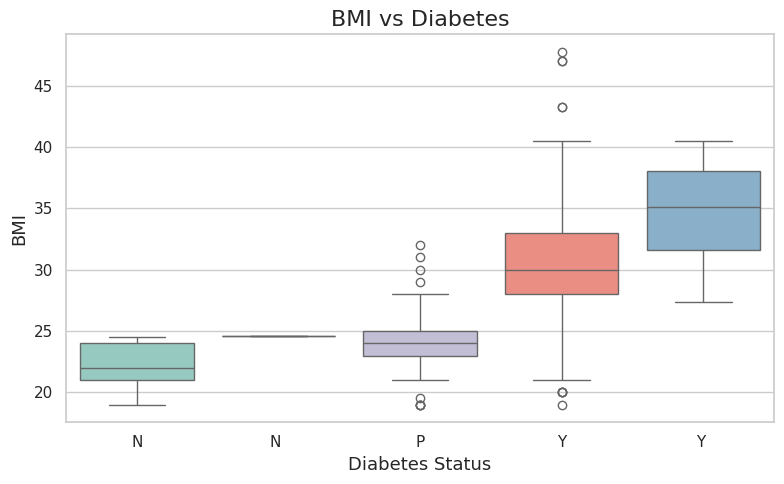

In [15]:
# =========================================
# Relationship Between ALL Numerical Features and Diabetes
# =========================================

# automatically detect numerical columns
numerical_features = df.select_dtypes(include=['int64','float64']).columns.tolist()

# remove target column from features
target = "CLASS"
if target in numerical_features:
    numerical_features.remove(target)

# plot relationship
for feature in numerical_features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x=target,
        y=feature,
        data=df,
        palette="Set3"
    )

    plt.title(f"{feature} vs Diabetes")
    plt.xlabel("Diabetes Status")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()


# =========================================
# STEP 4: Data Cleaning
# =========================================

In [18]:
import numpy as np

print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

print("\nDataset shape after removing duplicates:", df.shape)

# Replace invalid values (if 0 is not realistic)
df["BMI"] = df["BMI"].replace(0, np.nan)
df["HbA1c"] = df["HbA1c"].replace(0, np.nan)

# Fill missing values with median
df = df.fillna(df.median(numeric_only=True))


Missing Values:
ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64

Dataset shape after removing duplicates: (1000, 14)


# =========================================
# Encode Categorical Features
# =========================================

In [26]:
df_encoded = pd.get_dummies(df, drop_first=True)

# Show result
print(df_encoded.head())
print(df_encoded.columns)

    ID  No_Pation  AGE  Urea  Cr  HbA1c  Chol   TG  HDL  LDL  VLDL   BMI  \
0  502      17975   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0   
1  735      34221   26   4.5  62    4.9   3.7  1.4  1.1  2.1   0.6  23.0   
2  420      47975   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0   
3  680      87656   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0   
4  504      34223   33   7.1  46    4.9   4.9  1.0  0.8  2.0   0.4  21.0   

   Gender_M  Gender_f  CLASS_N   CLASS_P  CLASS_Y  CLASS_Y   
0     False     False     False    False    False     False  
1      True     False     False    False    False     False  
2     False     False     False    False    False     False  
3     False     False     False    False    False     False  
4      True     False     False    False    False     False  
Index(['ID', 'No_Pation', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL',
       'LDL', 'VLDL', 'BMI', 'Gender_M', 'Gender_f', 'CLASS_N ', 'CLASS_P',
       'CLASS_Y', 

# =========================================
# STEP 5: Feature & Target Separation
# =========================================

In [21]:
X = df.drop("CLASS", axis=1)
y = df["CLASS"]

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)


Features Shape: (1000, 13)
Target Shape: (1000,)


# =========================================
# STEP 6: Train / Validation / Test Split
# =========================================

In [27]:
# Fix column names
df_encoded.columns = df_encoded.columns.str.strip()

# Remove duplicate columns
df_encoded = df_encoded.loc[:, ~df_encoded.columns.duplicated()]

# Define target
y = df_encoded["CLASS_Y"]

# Define features
X = df_encoded.drop(
    ["CLASS_N", "CLASS_P", "CLASS_Y", "ID", "No_Pation"],
    axis=1
)

print(X.shape, y.shape)

(1000, 12) (1000,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (800, 12)
Test: (200, 12)


# =========================================
# Feature Scaling
# =========================================

In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================================
# 6. Sampling Techniques
# ======================================================


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from collections import Counter
import pandas as pd

# Sampling methods (updated)
sampling_methods = {
    "SMOTETomek": SMOTETomek(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "BorderlineSMOTE": BorderlineSMOTE(random_state=42)
}

results = []

print("Original Distribution:", Counter(y_train))

for name, sampler in sampling_methods.items():

    print("\n======================")
    print("Sampling Method:", name)

    # Apply sampling
    X_res, y_res = sampler.fit_resample(X_train, y_train)

    print("New Distribution:", Counter(y_res))

    # Train model
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_res, y_res)

    # Prediction
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    # Metrics
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()

    fnr = FN / (FN + TP)

    print("Recall:", recall)
    print("F1:", f1)
    print("AUC:", auc)
    print("FNR:", fnr)

    results.append([name, recall, f1, auc, fnr])

# Results table
results_df = pd.DataFrame(
    results,
    columns=["Sampling Method", "Recall", "F1 Score", "AUC", "FNR"]
)

print("\nFinal Sampling Comparison")
print(results_df.sort_values(by="Recall", ascending=False))

Original Distribution: Counter({True: 672, False: 128})

Sampling Method: SMOTETomek
New Distribution: Counter({True: 671, False: 671})
Recall: 0.9880952380952381
F1: 0.9851632047477745
AUC: 0.9837239583333333
FNR: 0.011904761904761904

Sampling Method: SMOTE
New Distribution: Counter({True: 672, False: 672})
Recall: 0.9880952380952381
F1: 0.9851632047477745
AUC: 0.9813058035714286
FNR: 0.011904761904761904

Sampling Method: BorderlineSMOTE
New Distribution: Counter({True: 672, False: 672})
Recall: 0.9761904761904762
F1: 0.9791044776119403
AUC: 0.972470238095238
FNR: 0.023809523809523808

Final Sampling Comparison
   Sampling Method    Recall  F1 Score       AUC       FNR
0       SMOTETomek  0.988095  0.985163  0.983724  0.011905
1            SMOTE  0.988095  0.985163  0.981306  0.011905
2  BorderlineSMOTE  0.976190  0.979104  0.972470  0.023810


# ======================================================
# 7. t-SNE Visualization
# ======================================================

Before SMOTETomek: Counter({True: 672, False: 128})
After SMOTETomek: Counter({True: 671, False: 671})


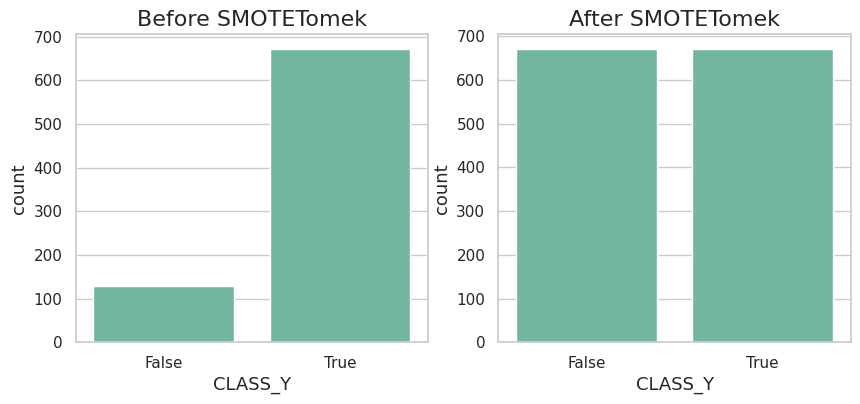

In [39]:
from imblearn.combine import SMOTETomek
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

print("Before SMOTETomek:", Counter(y_train))

# Apply SMOTETomek
smote_tomek = SMOTETomek(random_state=42)

X_res, y_res = smote_tomek.fit_resample(X_train, y_train)

print("After SMOTETomek:", Counter(y_res))

# Plot distribution
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(x=y_train)
plt.title("Before SMOTETomek")

plt.subplot(1,2,2)
sns.countplot(x=y_res)
plt.title("After SMOTETomek")

plt.show()

After SMOTETomek: (1342, 12)


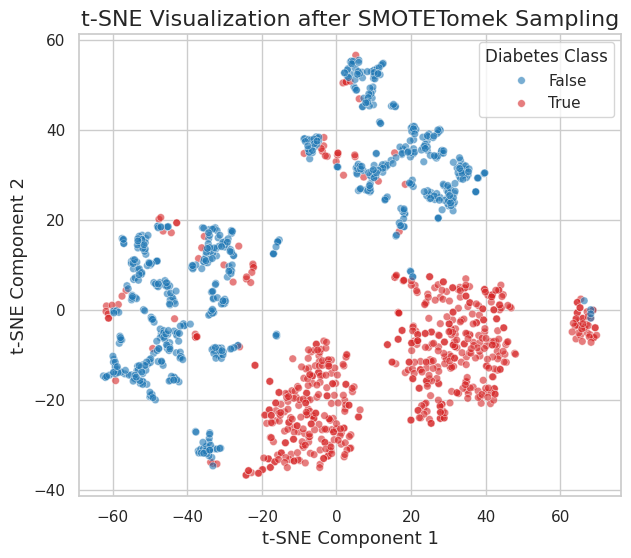

In [40]:
from imblearn.combine import SMOTETomek
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Apply SMOTETomek
smote_tomek = SMOTETomek(random_state=42)

X_res, y_res = smote_tomek.fit_resample(X_train, y_train)

print("After SMOTETomek:", X_res.shape)

# Apply t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate=200
)

X_tsne = tsne.fit_transform(X_res)

# Plot
plt.figure(figsize=(7,6))

sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=y_res,
    palette=["#1f77b4","#d62728"],
    alpha=0.6,
    s=30
)

plt.title("t-SNE Visualization after SMOTETomek Sampling")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.legend(title="Diabetes Class")
plt.show()

# Feature Importance with Random Forest

     Feature  Importance
9        BMI    0.353052
3      HbA1c    0.300511
0        AGE    0.171679
8       VLDL    0.041414
4       Chol    0.034938
5         TG    0.030939
7        LDL    0.019678
1       Urea    0.018792
2         Cr    0.014424
6        HDL    0.011299
10  Gender_M    0.003274
11  Gender_f    0.000000


/tmp/ipykernel_55/2756303771.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


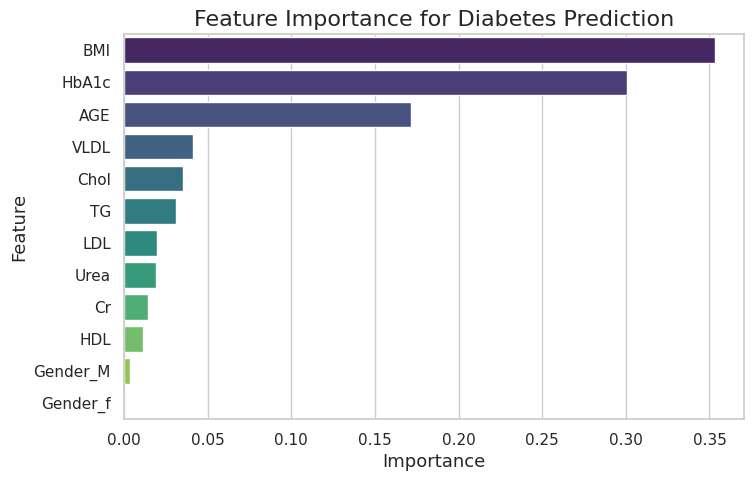

In [41]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_res, y_res)

# Get importance
importance = rf.feature_importances_

# Convert to dataframe
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

# Plot
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance,
    palette="viridis"
)

plt.title("Feature Importance for Diabetes Prediction")
plt.show()

# Permutation Importance

     Feature  Importance
3      HbA1c      0.1155
9        BMI      0.0665
4       Chol      0.0035
0        AGE      0.0010
10  Gender_M      0.0000
11  Gender_f      0.0000
5         TG     -0.0005
7        LDL     -0.0010
2         Cr     -0.0015
1       Urea     -0.0015
6        HDL     -0.0015
8       VLDL     -0.0015


/tmp/ipykernel_55/3089511694.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


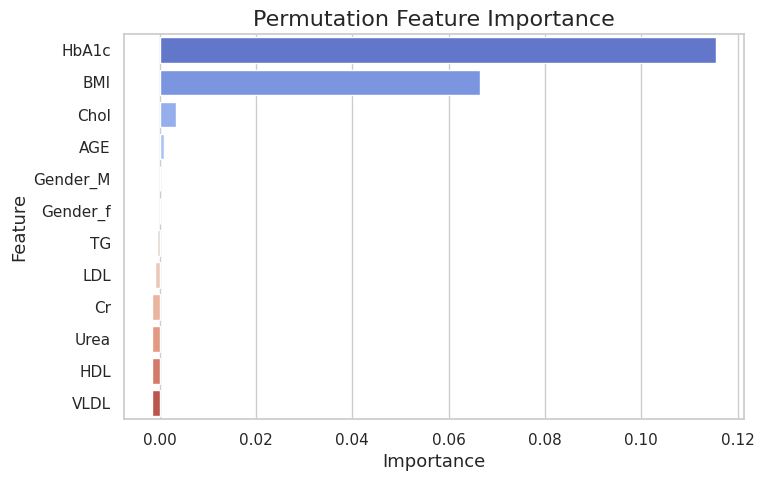

In [42]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_res, y_res)

# Permutation importance
perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
})

perm_importance = perm_importance.sort_values(
    by="Importance",
    ascending=False
)

print(perm_importance)

# Plot
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=perm_importance,
    palette="coolwarm"
)

plt.title("Permutation Feature Importance")
plt.show()